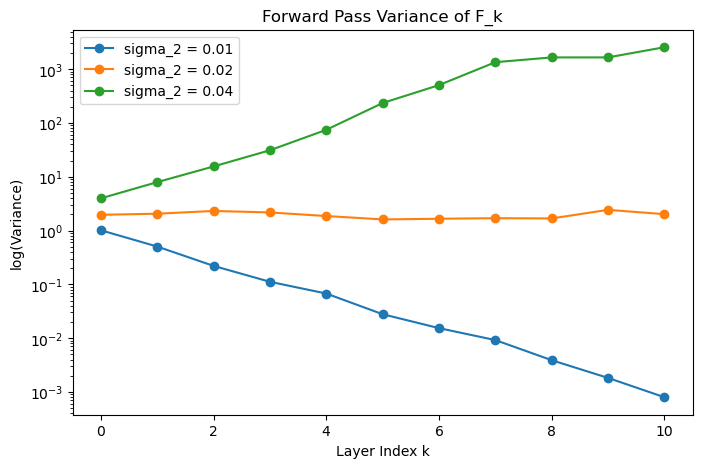

In [10]:
#Problem 2

import numpy as np
import matplotlib.pyplot as plt

D, B, K = 100, 100, 10
variances = [1/D, 2/D, 4/D]
forward_results = {}

for sigma_sq in variances:
    
    X = np.random.normal(0, 1, (D, B))
    weights = [np.random.normal(0, np.sqrt(sigma_sq), (D, D)) for _ in range(K + 1)]
    
    f_vars = []
   
    current_F = weights[0] @ X
    f_vars.append(np.var(current_F))
    
    
    for k in range(1, K + 1):
        H = np.maximum(0, current_F) 
        current_F = weights[k] @ H
        f_vars.append(np.var(current_F))
        
    forward_results[sigma_sq] = f_vars


plt.figure(figsize=(8, 5))
for sigma_sq, vars in forward_results.items():
    plt.plot(range(K + 1), vars, label=f"sigma_2 = {sigma_sq:.2f}", marker='o')
plt.yscale('log')
plt.title("Forward Pass Variance of F_k")
plt.xlabel("Layer Index k")
plt.ylabel("log(Variance)")
plt.legend()

plt.show()

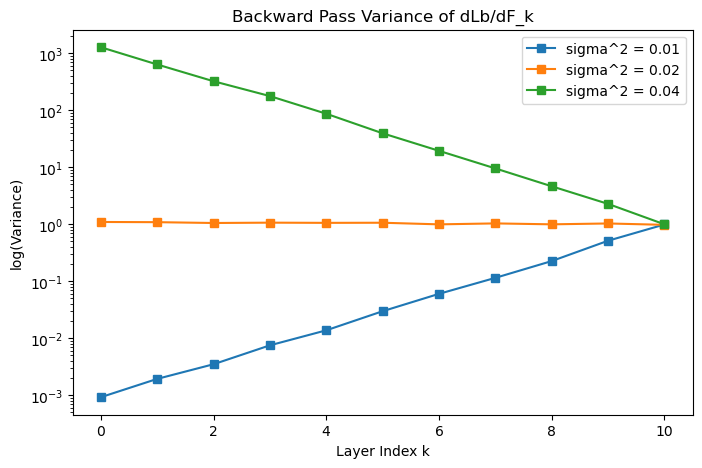

In [9]:
#Problem 3

backward_results = {}

for sigma_sq in variances:
    X = np.random.normal(0, 1, (D, B))
    weights = [np.random.normal(0, np.sqrt(sigma_sq), (D, D)) for _ in range(K + 1)]
    
    F_list = []
    current_F = weights[0] @ X
    F_list.append(current_F)
    for k in range(1, K + 1):
        current_F = weights[k] @ np.maximum(0, current_F)
        F_list.append(current_F)
        
 
    grad_F = np.random.normal(0, 1, (D, B))
    g_vars = [np.var(grad_F)]
    
    for k in range(K, 0, -1):
        
        grad_H = weights[k].T @ grad_F

        grad_F = grad_H * (F_list[k-1] > 0).astype(float)
        g_vars.append(np.var(grad_F))
        
    backward_results[sigma_sq] = g_vars[::-1] # Reverse to match layer order

plt.figure(figsize=(8, 5))
for sigma_sq, vars in backward_results.items():
    plt.plot(range(K + 1), vars, label=f"sigma^2 = {sigma_sq:.2f}", marker='s')
plt.yscale('log')
plt.title("Backward Pass Variance of dLb/dF_k")
plt.xlabel("Layer Index k")
plt.ylabel("log(Variance)")
plt.legend()
plt.show()